Step Size (h)   | Total Accumulated Error  
---------------------------------------------
0.01            | 0.45682                  
0.06            | 0.39259                  
0.11            | 0.43994                  
0.16            | 0.37720                  
0.21            | 0.38349                  
0.26            | 0.35594                  
0.31            | 0.42476                  
0.36            | 0.41280                  
0.41            | 0.35204                  
0.46            | 0.48436                  
0.51            | 0.37100                  
0.56            | 0.45872                  
0.61            | 0.53364                  
0.66            | 0.66760                  
0.71            | 0.71342                  
0.76            | 0.90742                  
0.81            | 1.12142                  
0.86            | 1.35542                  
0.91            | 1.60942                  
0.96            | 1.88342                  
1.01            | 1.03832     

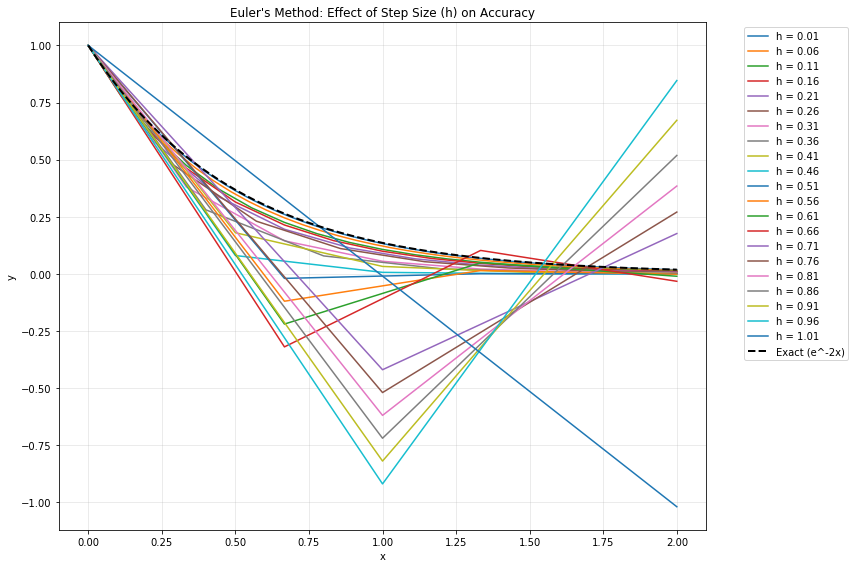

In [3]:
import numpy as np
import matplotlib.pyplot as plt


x_start, x_end = 0, 2
y_init = 1  # y(0) = 1

def f(x, y):
    return -2 * y

def exact_sol(x):
    return np.exp(-2 * x)


step_sizes = np.arange(0.01, 1.05, 0.05)

plt.figure(figsize=(12, 8))


print(f"{'Step Size (h)':<15} | {'Total Accumulated Error':<25}")
print("-" * 45)

for h in step_sizes:
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_euler = np.zeros(num_steps + 1)
    
    y_euler[0] = y_init
    
    
    for i in range(num_steps):
        y_euler[i + 1] = y_euler[i] + h * f(x_values[i], y_euler[i])
    
    
    y_true = exact_sol(x_values)
    pointwise_error = np.abs(y_true - y_euler)
    total_error = np.sum(pointwise_error)
    
    print(f"{h:<15.2f} | {total_error:<25.5f}")
    
    
    plt.plot(x_values, y_euler, label=f"h = {h:.2f}")


x_fine = np.linspace(x_start, x_end, 200)
plt.plot(x_fine, exact_sol(x_fine), 'k--', linewidth=2, label="Exact (e^-2x)")

plt.xlabel('x')
plt.ylabel('y')
plt.title("Euler's Method: Effect of Step Size (h) on Accuracy")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()